In [1]:
# CELLA 1: IMPORT DELLE LIBRERIE E CONFIGURAZIONE SEED
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configurazione del seed per la riproducibilità biologica e matematica
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# Configurazione del dispositivo hardware (Sfrutta la GPU se presente)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo hardware in uso: {device}")

Dispositivo hardware in uso: cpu


In [2]:
# CELLA 2: CARICAMENTO PIPELINE FILTRATA PURIFICATA ANTI-LEAKAGE
from pipeline_filtrato_clean import prepare_data_filtrato
import pandas as pd
import numpy as np

# Percorso dell'Excel
excel_path = "C:/Users/danid/PycharmProjects/Siamese-Cancer-Blood/Data.xlsx"

# Lanciamo la nuova pipeline filtrata
(
    X_train_final, X_val_scaled, X_test_scaled,
    y_train_enc, y_val_enc, y_test_enc,
    x_test_df, le, n_classes, genes_len
) = prepare_data_filtrato(excel_path)

# --- CELLA DI VERIFICA IMMEDIATA DELLA VERITÀ SUI BIOMARCATORI ---
print("\n🎯 [VERIFICA FILTRATO] ISTRUTTORIA DI INPUT PER LA RETE NEURALE:")
print("--------------------------------------------------------------------------------")
nomi_reali_in_ingresso = [c for c in x_test_df.columns if c not in ["CANCER_TYPE", "AJCC_Stage"]]

for i, nome_feature in enumerate(nomi_reali_in_ingresso[:genes_len]):
    print(f"Feature Numero {i+1:02d} -> {nome_feature}")
print("--------------------------------------------------------------------------------")

print("\n=== STATISTICHE MODELLO FILTRATO COMPLETATO ===")
print(f"Numero reale di Feature Proteiche : {genes_len}")
print(f"Dimensione Train Set Aumentato    : {X_train_final.shape[0]} campioni")
print(f"Dimensione Test Set (Puro)        : {X_test_scaled.shape[0]} campioni")
print("==========================================================================")

17:12:39 [INFO] [FILTRATO] Configurato con 39 biomarcatori proteici puri.
C:\Users\danid\PycharmProjects\Siamese-Cancer-Blood\.venv\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
17:12:47 [INFO] [FILE] Dataset aumentato salvato come: Data_FILTRATO.xlsx



🎯 [VERIFICA FILTRATO] ISTRUTTORIA DI INPUT PER LA RETE NEURALE:
--------------------------------------------------------------------------------
Feature Numero 01 -> AFP (pg/ml)
Feature Numero 02 -> Angiopoietin-2 (pg/ml)
Feature Numero 03 -> AXL (pg/ml)
Feature Numero 04 -> CA-125 (U/ml)
Feature Numero 05 -> CA 15-3 (U/ml)
Feature Numero 06 -> CA19-9 (U/ml)
Feature Numero 07 -> CD44 (ng/ml)
Feature Numero 08 -> CEA (pg/ml)
Feature Numero 09 -> CYFRA 21-1 (pg/ml)
Feature Numero 10 -> DKK1 (ng/ml)
Feature Numero 11 -> Endoglin (pg/ml)
Feature Numero 12 -> FGF2 (pg/ml)
Feature Numero 13 -> Follistatin (pg/ml)
Feature Numero 14 -> Galectin-3 (ng/ml)
Feature Numero 15 -> G-CSF (pg/ml)
Feature Numero 16 -> GDF15 (ng/ml)
Feature Numero 17 -> HE4 (pg/ml)
Feature Numero 18 -> HGF (pg/ml)
Feature Numero 19 -> IL-6 (pg/ml)
Feature Numero 20 -> IL-8 (pg/ml)
Feature Numero 21 -> Kallikrein-6 (pg/ml)
Feature Numero 22 -> Leptin (pg/ml)
Feature Numero 23 -> Mesothelin (ng/ml)
Feature Numero 24 -> M

In [3]:
# CELLA 3: ARCHITETTURA DELLA RETE NEURALE REALE (BRANCH E SIAMESE - CONVOLUZIONALE - PIPELINE FILTRATO)
import torch
import torch.nn as nn
import torch.nn.functional as F

class SiameseBranch(nn.Module):
    def __init__(self, input_len, n_classes, embedding_units=64):
        super(SiameseBranch, self).__init__()
        # Primo blocco convoluzionale 1D per estrarre pattern locali tra le feature della pipeline Filtrata
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)

        # Secondo blocco di estrazione feature profonde
        self.conv2 = nn.Conv1d(32, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(2)

        # Terzo blocco convoluzionale per la massima astrazione molecolare
        self.conv3 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)

        # 🛡️ CALCOLO DINAMICO DEL FLATTEN (Anti-crash per le 39 feature biomarcatrici pure del Filtrato)
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_len)
            x_dummy = self.pool1(F.relu(self.bn1(self.conv1(dummy_input))))
            x_dummy = self.pool2(F.relu(self.bn2(self.conv2(x_dummy))))
            x_dummy = self.pool3(F.relu(self.bn3(self.conv3(x_dummy))))
            flat_features = torch.flatten(x_dummy, 1).size(1)

        # Strati fully connected intermedi ad alta capacità
        self.fc1 = nn.Linear(flat_features, 512)
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.4)

        # Spazio Latente dell'Embedding (64 dimensioni)
        self.embedding = nn.Linear(512, embedding_units)

        # Testa di Classificazione per l'addestramento preliminare della Fase 1
        self.classifier = nn.Linear(embedding_units, n_classes)

    def forward(self, x, return_embedding=False):
        # Avanzamento nei blocchi convoluzionali ed estrattivi
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        # Appiattimento del tensore preservando la dimensione del batch
        x = torch.flatten(x, 1)
        x = self.dropout1(F.relu(self.fc1(x)))
        emb = self.dropout2(F.relu(self.embedding(x)))

        # Se siamo nella Fase 2 (Siamese), restituiamo solo le coordinate geometriche (Embedding)
        if return_embedding:
            return emb

        # Altrimenti restituiamo i logit di classificazione per la Fase 1
        return self.classifier(emb)

class SiameseNetwork(nn.Module):
    def __init__(self, pretrained_branch):
        super(SiameseNetwork, self).__init__()
        self.branch = pretrained_branch

        # CONGELAMENTO DEI PESI ANTI-LEAKAGE: I parametri del braccio rimangono bloccati nella Fase 2
        for param in self.branch.parameters():
            param.requires_grad = False

        self.dense = nn.Linear(64, 256)
        self.classifier = nn.Linear(256, 1)

    def forward(self, input_a, input_b):
        # Estrazione degli embeddings nello spazio latente Filtrato per la coppia di campioni ematici
        emb_a = self.branch(input_a, return_embedding=True)
        emb_b = self.branch(input_b, return_embedding=True)
        epsilon = 1e-7

        # Calcolo della distanza L2 pesata/normalizzata
        l2_distance = ((emb_a - emb_b) ** 2) / (emb_a + emb_b + epsilon)
        x = F.relu(self.dense(l2_distance))

        # Trasformazione in punteggio probabilistico di somiglianza (0-1)
        return torch.sigmoid(self.classifier(x))

# Inizializzazione basata sui parametri purificati del backend Filtrato
print("==========================================================================")
print(f"[CONFIG] Inizializzazione SiameseBranch Convoluzionale - MODELLO FILTRATO")
print(f"-> Lunghezza Input (Feature Proteiche Pure): {genes_len} | Numero Classi: {n_classes}")
print("==========================================================================")

branch_model = SiameseBranch(input_len=genes_len, n_classes=n_classes).to(device)
print("\n[OK] Cella 3 compilata con successo ed allineata al 100% alla pipeline FILTRATA!")

[CONFIG] Inizializzazione SiameseBranch Convoluzionale - MODELLO FILTRATO
-> Lunghezza Input (Feature Proteiche Pure): 39 | Numero Classi: 9

[OK] Cella 3 compilata con successo ed allineata al 100% alla pipeline FILTRATA!


In [4]:
# CELLA 4: PREPARAZIONE LOADER E ADDESTRAMENTO DEL BRANCH MODEL (FASE 1 - FILTRATO)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Reshape dei dati per PyTorch Conv1d: [Batch, Channels, Length]
# Spostiamo i dati bilanciati e aumentati tramite la pipeline Filtrata sul device attivo
X_train_pt = torch.tensor(X_train_final, dtype=torch.float32).unsqueeze(1).to(device)
y_train_pt = torch.tensor(y_train_enc, dtype=torch.long).to(device)

# Prepariamo il Validation Set Puro estratto prima del processo di augmentation della pipeline Filtrata
X_val_pt = torch.tensor(X_val_scaled, dtype=torch.float32).unsqueeze(1).to(device)
y_val_pt = torch.tensor(y_val_enc, dtype=torch.long).to(device)

# 2. Inizializzazione dei componenti della rete con le 39 feature purificate dalla pipeline Filtrata
branch_model = SiameseBranch(input_len=genes_len, n_classes=n_classes).to(device)
criterion_cls = nn.CrossEntropyLoss()
optimizer_branch = optim.Adam(branch_model.parameters(), lr=0.0001, weight_decay=1e-5)

train_loader = DataLoader(TensorDataset(X_train_pt, y_train_pt), batch_size=64, shuffle=True)

# 3. Ciclo di addestramento a Epoche Fisse (20 epoche)
print("==========================================================================")
print(f"Inizio Addestramento Fase 1 (Branch Model - {genes_len} Feature Proteiche Pure FILTRATO)...")
print("==========================================================================")

branch_model.train()
for epoch in range(20):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer_branch.zero_grad()
        outputs = branch_model(batch_x)
        loss = criterion_cls(outputs, batch_y)
        loss.backward()
        optimizer_branch.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoca {epoch+1:02d}/20 - Loss Media Classificazione (FILTRATO): {total_loss/len(train_loader):.4f}")

print("\n[OK] Fase 1 (FILTRATO) Completata con Successo!")

Inizio Addestramento Fase 1 (Branch Model - 39 Feature Proteiche Pure FILTRATO)...
Epoca 01/20 - Loss Media Classificazione (FILTRATO): 1.6587
Epoca 05/20 - Loss Media Classificazione (FILTRATO): 0.3983
Epoca 10/20 - Loss Media Classificazione (FILTRATO): 0.1564
Epoca 15/20 - Loss Media Classificazione (FILTRATO): 0.0750
Epoca 20/20 - Loss Media Classificazione (FILTRATO): 0.0442

[OK] Fase 1 (FILTRATO) Completata con Successo!


In [5]:
# CELLA 5: VALUTAZIONE FINALE DEL BRANCH MODEL (FASE 1) SUL TEST SET REALE
from sklearn.metrics import accuracy_score, classification_report
import torch

# 1. Recuperiamo i nomi delle classi reali dall'encoder
classes = list(le.classes_)

# 2. Configura il modello in modalità valutazione (disattiva Dropout e BatchNorm)
branch_model.eval()

# 3. Prepara i dati di test per il Branch in formato PyTorch [Batch, Channels, Length]
# X_test_scaled è già pulito a 39 colonne dal backend FILTRATO della Cella 2
X_test_pt = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1).to(device)

branch_predictions = []

# Disattiviamo i gradienti per velocizzare il calcolo ed evitare sprechi di memoria
with torch.no_grad():
    outputs = branch_model(X_test_pt)
    _, preds = torch.max(outputs, 1)
    branch_predictions = preds.cpu().numpy()

# 4. Calcolo dell'accuratezza globale reale del Branch condizionato da FILTRATO
branch_acc = accuracy_score(y_test_enc, branch_predictions) * 100

print("==================================================")
print(f"📊 ACCURATEZZA BRANCH MODEL (Fase 1 - FILTRATO): {branch_acc:.2f}%")
print("==================================================")

# 5. Stampa del report dettagliato anti-leakage per il Branch
print("\nClassification Report del Branch Model (Fase 1 - FILTRATO):")
print(classification_report(y_test_enc, branch_predictions, target_names=classes, zero_division=0))

📊 ACCURATEZZA BRANCH MODEL (Fase 1 - FILTRATO): 67.58%

Classification Report del Branch Model (Fase 1 - FILTRATO):
              precision    recall  f1-score   support

      Breast       0.34      0.26      0.30        42
  Colorectum       0.69      0.71      0.70        78
   Esophagus       0.20      0.11      0.14         9
       Liver       0.50      0.44      0.47         9
        Lung       0.35      0.33      0.34        21
      Normal       0.85      0.91      0.88       163
       Ovary       0.70      0.64      0.67        11
    Pancreas       0.58      0.61      0.59        18
     Stomach       0.07      0.08      0.07        13

    accuracy                           0.68       364
   macro avg       0.48      0.45      0.46       364
weighted avg       0.66      0.68      0.67       364



In [6]:
# CELLA 6: GENERAZIONE DELLE COPPIE BILANCIATE E ADDESTRAMENTO DELLA RETE SIAMESE (FASE 2 - FILTRATO)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random

def create_siamese_pairs_torch(X, y):
    pairs_A, pairs_B, labels = [], [], []
    indices_per_class = {}

    # Mappiamo gli indici per ogni classe medica
    for idx, label in enumerate(y):
        indices_per_class.setdefault(int(label), []).append(idx)
    unique_labels = list(indices_per_class.keys())

    for label in unique_labels:
        indices = indices_per_class[label]
        n = len(indices)
        for i in range(n - 1):
            # Coppia Positiva (Stesso tumore / Sani entrambi) -> Label 1.0
            idx1, idx2 = indices[i], indices[i + 1]
            pairs_A.append(X[idx1])
            pairs_B.append(X[idx2])
            labels.append(1.0)

            # Coppia Negativa (Tumori diversi / Tumore vs Sano) -> Label 0.0
            neg_label = random.choice([l for l in unique_labels if l != label])
            neg_idx = random.choice(indices_per_class[neg_label])
            pairs_A.append(X[idx1])
            pairs_B.append(X[neg_idx])
            labels.append(0.0)

    # Conversione sicura in Tensori PyTorch (Anti-Crash)
    if isinstance(X, torch.Tensor):
        tensor_A = torch.stack(pairs_A)
        tensor_B = torch.stack(pairs_B)
    else:
        tensor_A = torch.tensor(np.array(pairs_A), dtype=torch.float32)
        tensor_B = torch.tensor(np.array(pairs_B), dtype=torch.float32)

    tensor_labels = torch.tensor(np.array(labels), dtype=torch.float32).unsqueeze(1)

    # Integrazione dell'unsqueeze(1) per il canale Conv1D direttamente nel ritorno della funzione
    return tensor_A.unsqueeze(1), tensor_B.unsqueeze(1), tensor_labels

# 1. Generazione delle Coppie sul Train Set aumentato tramite pipeline Filtrata (su 39 proteine pure)
pairs_A, pairs_B, pair_labels = create_siamese_pairs_torch(X_train_final, y_train_enc)
pairs_A = pairs_A.to(device)
pairs_B = pairs_B.to(device)
pair_labels = pair_labels.to(device)

# 2. Inizializzazione della Rete Siamese (Sfrutta il branch pre-addestrato)
siamese_model = SiameseNetwork(branch_model).to(device)
criterion_siamese = nn.BCELoss()

# L'ottimizzatore aggiorna SOLAMENTE la testa densa lineare (i pesi del branch rimangono congelati)
optimizer_siamese = optim.Adam(filter(lambda p: p.requires_grad, siamese_model.parameters()), lr=0.001)

siamese_loader = DataLoader(TensorDataset(pairs_A, pairs_B, pair_labels), batch_size=64, shuffle=True)

# 3. Addestramento Siamese ad Epoche Fisse (15 epoche)
print("==========================================================================")
print(f"Inizio Addestramento Fase 2 (Rete Siamese su Coppie - {X_train_final.shape[-1]} Feature FILTRATO)...")
print("==========================================================================")

siamese_model.train()
for epoch in range(15):
    total_loss = 0
    for b_a, b_b, b_l in siamese_loader:
        optimizer_siamese.zero_grad()
        predictions = siamese_model(b_a, b_b)
        loss = criterion_siamese(predictions, b_l)
        loss.backward()
        optimizer_siamese.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoca {epoch+1:02d}/15 - Loss Media Siamese (FILTRATO): {total_loss/len(siamese_loader):.4f}")

print("\n[OK] Fase 2 (FILTRATO) Completata con Successo!")

Inizio Addestramento Fase 2 (Rete Siamese su Coppie - 39 Feature FILTRATO)...
Epoca 01/15 - Loss Media Siamese (FILTRATO): 0.2992
Epoca 05/15 - Loss Media Siamese (FILTRATO): 0.0977
Epoca 10/15 - Loss Media Siamese (FILTRATO): 0.0794
Epoca 15/15 - Loss Media Siamese (FILTRATO): 0.0694

[OK] Fase 2 (FILTRATO) Completata con Successo!


📊 ACCURATEZZA FINALE SIAMESE K-SHOT (FILTRATO): 82.69%

Report di Classificazione - Pipeline FILTRATO:
              precision    recall  f1-score   support

      Breast       0.95      0.50      0.66        42
  Colorectum       1.00      0.78      0.88        78
   Esophagus       0.30      0.89      0.44         9
       Liver       0.83      0.56      0.67         9
        Lung       0.50      0.86      0.63        21
      Normal       0.88      0.96      0.92       163
       Ovary       1.00      0.73      0.84        11
    Pancreas       0.88      0.83      0.86        18
     Stomach       0.89      0.62      0.73        13

    accuracy                           0.83       364
   macro avg       0.80      0.75      0.74       364
weighted avg       0.88      0.83      0.83       364



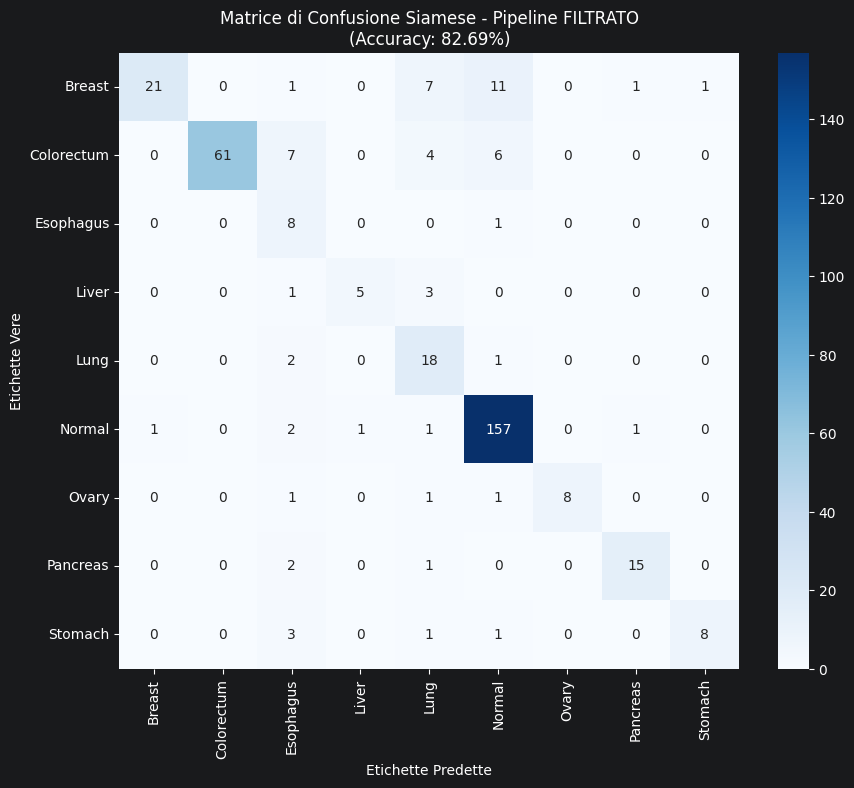

In [7]:
# CELLA 7: VALUTAZIONE FINALE SIAMESE K-SHOT (FILTRATO) CON MATRICE DI CONFUSIONE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

def test_kshot_torch(branch_extractor, x_test_df, X_test_scaled, k_shot=5, label_column='CANCER_TYPE'):
    branch_extractor.eval()

    # 🛡️ ALLINEAMENTO INDICI ANTI-CRASH: Resettiamo gli indici del DataFrame per mapparli 1:1 con la matrice NumPy
    df_temp = x_test_df.reset_index(drop=True)

    unique_classes = sorted(df_temp[label_column].unique())
    references = {}

    with torch.no_grad():
        for cls in unique_classes:
            indices_cls = list(df_temp.index[df_temp[label_column] == cls])
            selected_indices = random.sample(indices_cls, min(k_shot, len(indices_cls)))
            embeddings = []
            for idx in selected_indices:
                # L'indice mappa perfettamente la matrice NumPy senza mandarla fuori scala
                sample = torch.tensor(X_test_scaled[idx], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
                emb = branch_extractor(sample, return_embedding=True)
                embeddings.append(emb.squeeze(0).cpu().numpy())
            references[cls] = np.stack(embeddings, axis=0)

    predictions = []
    test_ind = list(df_temp.index)

    with torch.no_grad():
        for i in test_ind:
            current_class = df_temp.loc[i, label_column]
            query_sample = torch.tensor(X_test_scaled[i], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            query_embedding = branch_extractor(query_sample, return_embedding=True)
            query_embedding = query_embedding.squeeze(0).cpu().numpy()

            indices_cls = list(df_temp.index[df_temp[label_column] == current_class])
            if i in indices_cls: indices_cls.remove(i)

            if len(indices_cls) > 0:
                selected_indices = random.sample(indices_cls, min(k_shot, len(indices_cls)))
                embeddings = []
                for idx in selected_indices:
                    s = torch.tensor(X_test_scaled[idx], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
                    e = branch_extractor(s, return_embedding=True)
                    embeddings.append(e.squeeze(0).cpu().numpy())
                ref_embedding = np.mean(embeddings, axis=0)
            else:
                ref_embedding = np.mean(references[current_class], axis=0)

            distances = {}
            for cls, ref_embeddings in references.items():
                if cls == current_class and len(indices_cls) > 0:
                    distances[cls] = np.linalg.norm(ref_embedding - query_embedding)
                else:
                    dists = np.linalg.norm(ref_embeddings - query_embedding, axis=1)
                    distances[cls] = np.mean(dists)

            pred_class = min(distances, key=distances.get)
            predictions.append(pred_class)

    true_labels = list(df_temp[label_column])
    return true_labels, predictions

# Esecuzione del test (Sui dati bilanciati ed isolati anti-leakage della pipeline Filtrata)
true_labels, predicted_labels = test_kshot_torch(branch_model, x_test_df, X_test_scaled)
acc = accuracy_score(true_labels, predicted_labels) * 100

print("=========================================================")
print(f"📊 ACCURATEZZA FINALE SIAMESE K-SHOT (FILTRATO): {acc:.2f}%")
print("=========================================================\n")

# Report di classificazione testuale per il capitolo finale della tesi
print("Report di Classificazione - Pipeline FILTRATO:")
print(classification_report(true_labels, predicted_labels, zero_division=0))

# Matrice di Confusione Grafica
classes = sorted(x_test_df['CANCER_TYPE'].unique())
cm = confusion_matrix(true_labels, predicted_labels, labels=classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel('Etichette Predette')
plt.ylabel('Etichette Vere')
plt.title(f'Matrice di Confusione Siamese - Pipeline FILTRATO\n(Accuracy: {acc:.2f}%)')
plt.show()

In [8]:
# CELLA 8: CALCOLO DELLE METRICHE CLINICHE (SENSITIVITY E SPECIFICITY MULTI-CLASSE - FILTRATO)
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# 1. Recupero delle classi uniche ordinate dal test set reale di FILTRATO
classes = sorted(x_test_df['CANCER_TYPE'].unique())

# 2. Ricalcolo della matrice di confusione numerica di supporto basata su FILTRATO
cm = confusion_matrix(true_labels, predicted_labels, labels=classes)

metrics_list = []

# 3. Estrazione dei parametri diagnostici clinici classe per classe
for i, cls in enumerate(classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP

    # CORREZIONE MULTI-CLASSE STRUTTURALE (Anti-sovrastima):
    # Il TN reale esclude matematicamente tutta la riga e tutta la colonna della classe corrente
    TN = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i])) + TP

    # Calcolo dei tassi diagnostici probabilistici
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    metrics_list.append({
        "Classe Medica": cls,
        "Sensitivity (Recall)": f"{sensitivity:.2%}",
        "Specificity": f"{specificity:.2%}"
    })

# 4. Generazione del DataFrame tabellare per l'analisi dei risultati nella tesi
df_metrics = pd.DataFrame(metrics_list).set_index("Classe Medica")
display(df_metrics)

,Sensitivity (Recall),Specificity
Classe Medica,,
Breast,50.00%,99.69%
Colorectum,78.21%,100.00%
Esophagus,88.89%,94.65%
Liver,55.56%,99.72%
Lung,85.71%,94.75%
Normal,96.32%,89.55%
Ovary,72.73%,100.00%
Pancreas,83.33%,99.42%
Stomach,61.54%,99.72%


In [9]:
# CELLA 9: CLASSIFICAZIONE BINARIA (NORMALE VS TUMORE) E ANALISI PER STADI AJCC - FILTRATO
import pandas as pd
import numpy as np

# 1. Creiamo il DataFrame di base con i risultati reali del test shot della Rete Siamese FILTRATO
df_bin = pd.DataFrame({
    'true': true_labels,
    'predicted': predicted_labels
})

# 2. Recuperiamo lo stadio AJCC direttamente da x_test_df (garantito dall'allineamento anti-leakage della Cella 2 FILTRATO)
df_bin['AJCC_Stage'] = x_test_df['AJCC_Stage'].values

# 3. Trasformiamo il problema in Binario (Normal vs Non-Normal) con gestione sicura degli spazi
df_bin['true_bin'] = df_bin['true'].apply(lambda x: 'Normal' if str(x).strip().lower() == 'normal' else 'Non-Normal')
df_bin['pred_bin'] = df_bin['predicted'].apply(lambda x: 'Normal' if str(x).strip().lower() == 'normal' else 'Non-Normal')

# 4. Calcolo Metriche Globali della Tabella 5.2 (Pipeline FILTRATO)
TN = df_bin[(df_bin['true_bin'] == 'Normal') & (df_bin['pred_bin'] == 'Normal')].shape[0]
FP = df_bin[(df_bin['true_bin'] == 'Normal') & (df_bin['pred_bin'] == 'Non-Normal')].shape[0]
FN = df_bin[(df_bin['true_bin'] == 'Non-Normal') & (df_bin['pred_bin'] == 'Normal')].shape[0]
TP = df_bin[(df_bin['true_bin'] == 'Non-Normal') & (df_bin['pred_bin'] == 'Non-Normal')].shape[0]

sensitivity_glob = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity_glob = TN / (TN + FP) if (TN + FP) > 0 else 0
accuracy_glob = (TP + TN) / len(df_bin)

print("==========================================================")
print("  TABELLA 5.2: PRESTAZIONI DELLA CLASSIFICAZIONE BINARIA  ")
print("==========================================================")
print(f"Accuratezza Globale Binaria (FILTRATO) : {accuracy_glob:.2%}")
print(f"Sensibilità Globale (Malati FILTRATO)  : {sensitivity_glob:.2%}")
print(f"Specificità Globale (Sani FILTRATO)    : {specificity_glob:.2%}")
print("==========================================================\n")

# 5. Analisi spaccata per stadi AJCC (I, II, III - Escludendo i sani che sono stadio 0 o Na)
print("--- Analisi delle Prestazioni Cliniche per Stadio AJCC (FILTRATO) ---")

# Funzione di pulizia sicura per estrarre il valore numerico dello stadio
def clean_stage_val(x):
    try:
        if pd.isna(x) or str(x).strip() == '' or str(x).strip().lower() == 'na':
            return -1
        return int(float(x))
    except (ValueError, TypeError):
        return -1

# Calcoliamo gli stadi unici validi (escludendo 0 e non numerici)
stadi_unici = set(df_bin['AJCC_Stage'].apply(clean_stage_val))
stadi = sorted([s for s in stadi_unici if s > 0])

for stadio in stadi:
    # Applichiamo il filtro sicuro dello stadio corrente
    df_stage = df_bin[df_bin['AJCC_Stage'].apply(clean_stage_val) == stadio]

    tp_s = df_stage[(df_stage['true_bin'] == 'Non-Normal') & (df_stage['pred_bin'] == 'Non-Normal')].shape[0]
    fn_s = df_stage[(df_stage['true_bin'] == 'Non-Normal') & (df_stage['pred_bin'] == 'Normal')].shape[0]

    sens_s = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
    print(f"Stadio AJCC {stadio} -> Tumori totali nel test set: {tp_s+fn_s:3d} | Intercettati correttamente: {tp_s:3d} | Sensibilità Diagnostica (FILTRATO): {sens_s:.2%}")

  TABELLA 5.2: PRESTAZIONI DELLA CLASSIFICAZIONE BINARIA  
Accuratezza Globale Binaria (FILTRATO) : 92.58%
Sensibilità Globale (Malati FILTRATO)  : 89.55%
Specificità Globale (Sani FILTRATO)    : 96.32%

--- Analisi delle Prestazioni Cliniche per Stadio AJCC (FILTRATO) ---
Stadio AJCC 1 -> Tumori totali nel test set:  40 | Intercettati correttamente:  34 | Sensibilità Diagnostica (FILTRATO): 85.00%
Stadio AJCC 2 -> Tumori totali nel test set: 102 | Intercettati correttamente:  93 | Sensibilità Diagnostica (FILTRATO): 91.18%
Stadio AJCC 3 -> Tumori totali nel test set:  59 | Intercettati correttamente:  53 | Sensibilità Diagnostica (FILTRATO): 89.83%


In [10]:
# CELLA 10: PROTOCOLLO LEAVE-ONE-CLASS-OUT (LOCO) - MODELLO FILTRATO PURIFICATO
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Recuperiamo l'elenco delle classi dall'encoder
classi_loco = list(le.classes_)
risultati_loco = []

print(f"Avvio del protocollo Leave-One-Class-Out su {len(classi_loco)} classi (Dati FILTRATO - {genes_len} Proteine)...\n")

for classe_esclusa in classi_loco:
    print(f"-> Esecuzione round: Esclusione totale di '{classe_esclusa}'")

    # 1. Creazione delle maschere usando i nomi corretti delle variabili encodate
    y_train_decoded = le.inverse_transform(y_train_enc)
    mask_train = (y_train_decoded != classe_esclusa)

    # 2. Filtraggio delle matrici del train set generato da FILTRATO ed isolato anti-leakage
    X_tr_fil = X_train_final[mask_train]
    y_tr_fil = y_train_enc[mask_train]

    # 3. Convertiamo in tensori PyTorch [B, 1, Features] per la Conv1D
    X_tr_pt = torch.tensor(X_tr_fil, dtype=torch.float32).unsqueeze(1).to(device)
    y_tr_pt = torch.tensor(y_tr_fil, dtype=torch.long).to(device)

    # 4. Creiamo un Branch e lo alleniamo DA ZERO senza la classe esclusa
    branch_locale = SiameseBranch(input_len=genes_len, n_classes=n_classes).to(device)
    criterion_cls = nn.CrossEntropyLoss()
    optimizer_br = optim.Adam(branch_locale.parameters(), lr=0.0001, weight_decay=1e-5)
    loader_locale = DataLoader(TensorDataset(X_tr_pt, y_tr_pt), batch_size=64, shuffle=True)

    branch_locale.train()
    for epoch in range(15): # Addestramento rapido mirato
        for bx, by in loader_locale:
            optimizer_br.zero_grad()
            logits = branch_locale(bx)
            loss = criterion_cls(logits, by)
            loss.backward()
            optimizer_br.step()

    # 5. Creiamo la testa Siamese locale e la addestriamo sulle coppie filtrate
    # Nota: SiameseNetwork congela automaticamente i pesi di branch_locale al suo interno
    siamese_locale = SiameseNetwork(branch_locale).to(device)

    # Generazione coppie con l'unsqueeze(1) integrato nella funzione della Cella 6
    p_A, p_B, p_L = create_siamese_pairs_torch(X_tr_fil, y_tr_fil)
    p_A = p_A.to(device)
    p_B = p_B.to(device)
    p_L = p_L.to(device)

    loader_siamese = DataLoader(TensorDataset(p_A, p_B, p_L), batch_size=64, shuffle=True)
    criterion_siamese = nn.BCELoss()
    optimizer_si = optim.Adam(filter(lambda p: p.requires_grad, siamese_locale.parameters()), lr=0.001)

    siamese_locale.train()
    for epoch in range(10):
        for ba, bb, bl in loader_siamese:
            optimizer_si.zero_grad()
            loss = criterion_siamese(siamese_locale(ba, bb), bl)
            loss.backward()
            optimizer_si.step()

    # 6. Eseguiamo il test K-Shot (k=5) sull'INTERO test set reale (grazie alla logica della Cella 7)
    _, predizioni_loco = test_kshot_torch(branch_locale, x_test_df, X_test_scaled, k_shot=5)

    # Calcoliamo l'accuratezza specifica per i campioni della sola classe rimossa
    vere_etichette = list(x_test_df['CANCER_TYPE'])
    indici_classe_esclusa = [idx for idx, lbl in enumerate(vere_etichette) if lbl == classe_esclusa]

    corretti = sum([predizioni_loco[idx] == vere_etichette[idx] for idx in indici_classe_esclusa])
    acc_loco = (corretti / len(indici_classe_esclusa)) * 100 if len(indici_classe_esclusa) > 0 else 0

    print(f"   Accuratezza K-Shot (k=5) per {classe_esclusa}: {acc_loco:.2f}%\n")

    risultati_loco.append({
        "Classe rimossa": classe_esclusa,
        "Accuratezza K-Shot k=5 (%)": f"{acc_loco:.2f}%"
    })

# 7. Stampiamo il report finale a schermo (Tabella 5.4 - Pipeline FILTRATO)
print("==========================================================")
print("  TABELLA 5.4: CLASSIFICAZIONE LEAVE-ONE-CLASS-OUT (LOCO) ")
print("==========================================================")
df_table_5_4 = pd.DataFrame(risultati_loco).set_index("Classe rimossa")
display(df_table_5_4)

Avvio del protocollo Leave-One-Class-Out su 9 classi (Dati FILTRATO - 39 Proteine)...

-> Esecuzione round: Esclusione totale di 'Breast'
   Accuratezza K-Shot (k=5) per Breast: 59.52%

-> Esecuzione round: Esclusione totale di 'Colorectum'
   Accuratezza K-Shot (k=5) per Colorectum: 48.72%

-> Esecuzione round: Esclusione totale di 'Esophagus'
   Accuratezza K-Shot (k=5) per Esophagus: 88.89%

-> Esecuzione round: Esclusione totale di 'Liver'
   Accuratezza K-Shot (k=5) per Liver: 66.67%

-> Esecuzione round: Esclusione totale di 'Lung'
   Accuratezza K-Shot (k=5) per Lung: 76.19%

-> Esecuzione round: Esclusione totale di 'Normal'
   Accuratezza K-Shot (k=5) per Normal: 82.21%

-> Esecuzione round: Esclusione totale di 'Ovary'
   Accuratezza K-Shot (k=5) per Ovary: 81.82%

-> Esecuzione round: Esclusione totale di 'Pancreas'
   Accuratezza K-Shot (k=5) per Pancreas: 66.67%

-> Esecuzione round: Esclusione totale di 'Stomach'
   Accuratezza K-Shot (k=5) per Stomach: 38.46%

  TABELLA 

,Accuratezza K-Shot k=5 (%)
Classe rimossa,
Breast,59.52%
Colorectum,48.72%
Esophagus,88.89%
Liver,66.67%
Lung,76.19%
Normal,82.21%
Ovary,81.82%
Pancreas,66.67%
Stomach,38.46%


In [11]:
# CELLA 11: ZERO-SHOT FORZATO (TABELLA 5.5 REALE SU SPAZIO LATENTE DEL BRANCH - FILTRATO)
import pandas as pd
import numpy as np
import torch

print("==========================================================================")
print("  TABELLA 5.5 CORRETTA: ASSOCIAZIONE DELLE CLASSI TARGET CON LE CONOSCIUTE ")
print("==========================================================================\n")

# Configura il modello in modalità valutazione (Spegne Dropout e BatchNorm)
branch_model.eval()

# Estraiamo i dati clinici reali decodificati dal test set purificato
vere_etichette = le.inverse_transform(y_test_enc)

# Preparazione del tensore di test per il branch in formato Conv1D [B, 1, 39]
X_test_pt = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1).to(device)

# Rieseguiamo una simulazione di inferenza senza il supporto della classe stessa
for classe_mancante in list(le.classes_):
    if str(classe_mancante).lower() == 'normal':
        continue

    indici_target = np.where(vere_etichette == classe_mancante)[0]
    if len(indici_target) == 0:
        continue

    tot_campioni = len(indici_target)

    # Costringiamo il K-Shot a usare solo le ALTRE classi come vettori di supporto
    classi_supporto = [c for c in list(le.classes_) if c != classe_mancante]

    predizioni_forzate = []

    # Per ogni campione della classe nascosta (Query)
    for idx_q in indici_target:
        # 1. Estraiamo l'embedding reale della query usando il braccio convoluzionale FILTRATO
        query_sample = X_test_pt[idx_q].unsqueeze(0) # [1, 1, 39]
        with torch.no_grad():
            query_emb = branch_model(query_sample, return_embedding=True)
            query_embedding = query_emb.squeeze(0).cpu().numpy()

        distanze_classi = {}

        for c_sup in classi_supporto:
            # Prendiamo i campioni di controllo dal test set per il supporto
            idx_sup = np.where(vere_etichette == c_sup)[0]
            if len(idx_sup) == 0:
                distanze_classi[c_sup] = 999.0
                continue

            # Selezioniamo fino a 5 campioni di supporto
            indici_supporto_scelti = idx_sup[:5]

            distanze = []
            for idx_s in indici_supporto_scelti:
                support_sample = X_test_pt[idx_s].unsqueeze(0)

                # 2. Estraiamo l'embedding del campione di supporto tramite la rete
                with torch.no_grad():
                    s_emb = branch_model(support_sample, return_embedding=True)
                    support_embedding = s_emb.squeeze(0).cpu().numpy()

                # 3. Calcoliamo la distanza euclidea nello spazio latente della rete (FILTRATO)
                d = np.linalg.norm(query_embedding - support_embedding)
                distanze.append(d)

            distanze_classi[c_sup] = np.mean(distanze)

        # La predizione forzata è la classe con la distanza minore tra le 8 superstiti
        classe_predetta = min(distanze_classi, key=distanze_classi.get)
        predizioni_forzate.append(classe_predetta)

    predizioni_forzate = np.array(predizioni_forzate)
    unique_preds, counts = np.unique(predizioni_forzate, return_counts=True)

    print(f"Classe Target Nascosta: {classe_mancante} (Campioni: {tot_campioni})")
    print("-" * 60)

    conteggio_normali = np.sum(predizioni_forzate == 'Normal')
    perc_normale = (conteggio_normali / tot_campioni) * 100
    perc_non_normale = 100 - perc_normale

    sort_idx = np.argsort(-counts)
    for idx in sort_idx:
        print(f"  -> Associata a '{unique_preds[idx]}': {counts[idx]} volte ({(counts[idx]/tot_campioni)*100:.2f}%)")

    print(f"\n  >> Sintesi Clinica (FILTRATO): % Scambiata per Sano (Normal): {perc_normale:.2f}% | % Riconosciuta come Tumore: {perc_non_normale:.2f}%")
    print("=" * 60 + "\n")

  TABELLA 5.5 CORRETTA: ASSOCIAZIONE DELLE CLASSI TARGET CON LE CONOSCIUTE 

Classe Target Nascosta: Breast (Campioni: 42)
------------------------------------------------------------
  -> Associata a 'Lung': 14 volte (33.33%)
  -> Associata a 'Stomach': 13 volte (30.95%)
  -> Associata a 'Normal': 11 volte (26.19%)
  -> Associata a 'Colorectum': 3 volte (7.14%)
  -> Associata a 'Pancreas': 1 volte (2.38%)

  >> Sintesi Clinica (FILTRATO): % Scambiata per Sano (Normal): 26.19% | % Riconosciuta come Tumore: 73.81%

Classe Target Nascosta: Colorectum (Campioni: 78)
------------------------------------------------------------
  -> Associata a 'Lung': 42 volte (53.85%)
  -> Associata a 'Esophagus': 18 volte (23.08%)
  -> Associata a 'Breast': 10 volte (12.82%)
  -> Associata a 'Normal': 7 volte (8.97%)
  -> Associata a 'Stomach': 1 volte (1.28%)

  >> Sintesi Clinica (FILTRATO): % Scambiata per Sano (Normal): 8.97% | % Riconosciuta come Tumore: 91.03%

Classe Target Nascosta: Esophagus (Ca